# Determining the seasonal extent of waterbodies with Sentinel 2 <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with `DEA Sandbox` environment
* **Products used:** 
[ga_s2am_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2am_ard_3),
[ga_s2bm_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2bm_ard_3),
[ga_s2cm_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2cm_ard_3)

## Background
The United Nations have prescribed 17 "Sustainable Development Goals" (SDGs). This notebook attempts to monitor SDG Indicator 6.6.1 - change in the extent of water-related ecosystems. Indicator 6.6.1 has 4 sub-indicators:
>    i. The spatial extent of water-related ecosystems <br>
>    ii. The quantity of water contained within these ecosystems <br>
>    iii. The quality of water within these ecosystems <br>
>    iv. The health or state of these ecosystems. <br>

This notebook primarily focuses on the first sub-indicator, spatial extents.


## Description

The notebook demonstrates how to:

1. Load satellite data over the water body of interest
2. Calculate the Modified Normalized Difference Water Index (MNDWI) 
3. Resample the time series of MNDWI to seasonal medians
4. Generate an animation of the water extent time series
5. Calculate and plot a time series of seasonal water extent (in square kilometres)
6. Find the minimum and maximum water extents in the time series and plot them.
7. Compare two nominated time periods, and plot where the waterbody extent has changed.

***

## Getting started
To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

In [32]:
%matplotlib inline

import datacube
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from dea_tools.bandindices import calculate_indices
from dea_tools.dask import create_local_dask_cluster
from dea_tools.datahandling import load_ard
from dea_tools.plotting import display_map, xr_animation

from IPython.display import Image
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

### Connect to the datacube

Activate the datacube database, which provides functionality for loading and displaying stored Earth observation data.

In [33]:
dc = datacube.Datacube(app="Seasonal_water_extents")

### Set up a Dask cluster

Dask can be used to better manage memory use and conduct the analysis in parallel. 
For an introduction to using Dask with Digital Earth Australia, see the [Dask notebook](../Beginners_guide/09_Parallel_processing_with_Dask.ipynb).

>**Note**: We recommend opening the Dask processing window to view the different computations that are being executed; to do this, see the *Dask dashboard in JupyterLab* section of the [Dask notebook](../Beginners_guide/09_Parallel_processing_with_Dask.ipynb).

To activate Dask, set up the local computing cluster using the cell below.

In [34]:
create_local_dask_cluster()

/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 32957 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jburrow5@myune.edu.au/proxy/32957/status,
Dashboard: /user/jburrow5@myune.edu.au/proxy/32957/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38099,Workers: 1
Dashboard: /user/jburrow5@myune.edu.au/proxy/32957/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:34233,Total threads: 2
Dashboard: /user/jburrow5@myune.edu.au/proxy/43315/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:36675,


### Analysis parameters

The following cell sets the parameters, which define the area of interest and the length of time to conduct the analysis over.

The parameters are:

* `lat`: The central latitude to analyse (e.g. -35.0958).
* `lon` : The central longitude to analyse (e.g. 149.4249).
* `lat_buffer` : The number of degrees to load around the central latitude.
* `lon_buffer` : The number of degrees to load around the central longitude.
* `start_year` and `end_year`: The date range to analyse (e.g. `('2017', '2020')`.


**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.
The example covers Lake George near Canberra, Australia.


In [35]:
# Define the area of interest
lat = -10.6
lon = 142.295

lat_buffer = 0.005
lon_buffer = 0.005

# Combine central lat,lon with buffer to get area of interest
lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)

# Define the start year and end year
start_year = "1995"
end_year = "2022"

### View the area of interest on an interactive map
The next cell will display the selected area on an interactive map.
The red border represents the area of interest of the study.
Zoom in and out to get a better understanding of the area of interest.
Clicking anywhere on the map will reveal the latitude and longitude coordinates of the clicked point.

In [36]:
display_map(lon_range, lat_range)

### Load cloud-masked satellite data

The code below will create a query dictionary for our region of interest, and then load Sentinel 2 satellite data.
For more information on loading data, see the [Loading data notebook](../Beginners_guide/04_Loading_data.ipynb).

In [37]:
# Create a query object
query = {
    "x": lon_range,
    "y": lat_range,
    "resolution": (-20, 20),
    "time": (start_year, end_year),
    "dask_chunks": {"time": 1, "x": 2048, "y": 2048},
}

# Load Sentinel 2 data
ds = load_ard(
    dc=dc,
    products=["ga_s2am_ard_3", "ga_s2bm_ard_3", "ga_s2cm_ard_3"],
    measurements=["green", "nbart_swir_2", "nbart_swir_3"],
    cloud_mask="s2cloudless",
    min_gooddata=0.9,
    group_by="solar_day",
    **query
)

ds

Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
    ga_s2cm_ard_3
Counting good quality pixels for each time step using s2cloudless


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Filtering to 165 out of 598 time steps with at least 90.0% good quality pixels
Applying s2cloudless pixel quality/cloud mask
Returning 165 time steps as a dask array


<xarray.Dataset> Size: 7MB
Dimensions:       (time: 165, y: 59, x: 62)
Coordinates:
  * time          (time) datetime64[ns] 1kB 2015-12-07T00:48:32.359000 ... 20...
  * y             (y) float64 472B -1.159e+06 -1.159e+06 ... -1.16e+06 -1.16e+06
  * x             (x) float64 496B 1.154e+06 1.154e+06 ... 1.155e+06 1.155e+06
    spatial_ref   int32 4B 3577
Data variables:
    green         (time, y, x) float32 2MB dask.array<chunksize=(1, 59, 62), meta=np.ndarray>
    nbart_swir_2  (time, y, x) float32 2MB dask.array<chunksize=(1, 59, 62), meta=np.ndarray>
    nbart_swir_3  (time, y, x) float32 2MB dask.array<chunksize=(1, 59, 62), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Calculate the MNDWI water index

In [38]:
# Calculate MNDWI and add it to the loaded data set
ds = calculate_indices(ds=ds, index="MNDWI", collection="ga_s2_3", drop=True)

Dropping bands ['green', 'nbart_swir_2', 'nbart_swir_3']


### Resample time series

Due to many factors (e.g. cloud obscuring the region, missed cloud cover in the fmask layer) the data main contain gaps or noise. Here, we will resample the data to ensure we working with a consistent time series.

To do this we resample the data to seasonal time steps using medians.

These calculations will take several minutes to complete as we will run `.compute()`, triggering all the tasks we scheduled above and bringing the arrays into memory.


In [39]:
%%time
sample_frequency = "QS-DEC"  # quarterly starting in DEC, i.e. seasonal

# Resample using medians
print("Calculating MNDWI seasonal medians...")
mndwi = ds["MNDWI"].resample(time=sample_frequency).median().compute()

# Drop any all-NA seasons
mndwi = mndwi.dropna(dim="time", how="all")

Calculating MNDWI seasonal medians...
CPU times: user 4.45 s, sys: 734 ms, total: 5.18 s
Wall time: 44.6 s


### Facet plot the MNDWI time steps

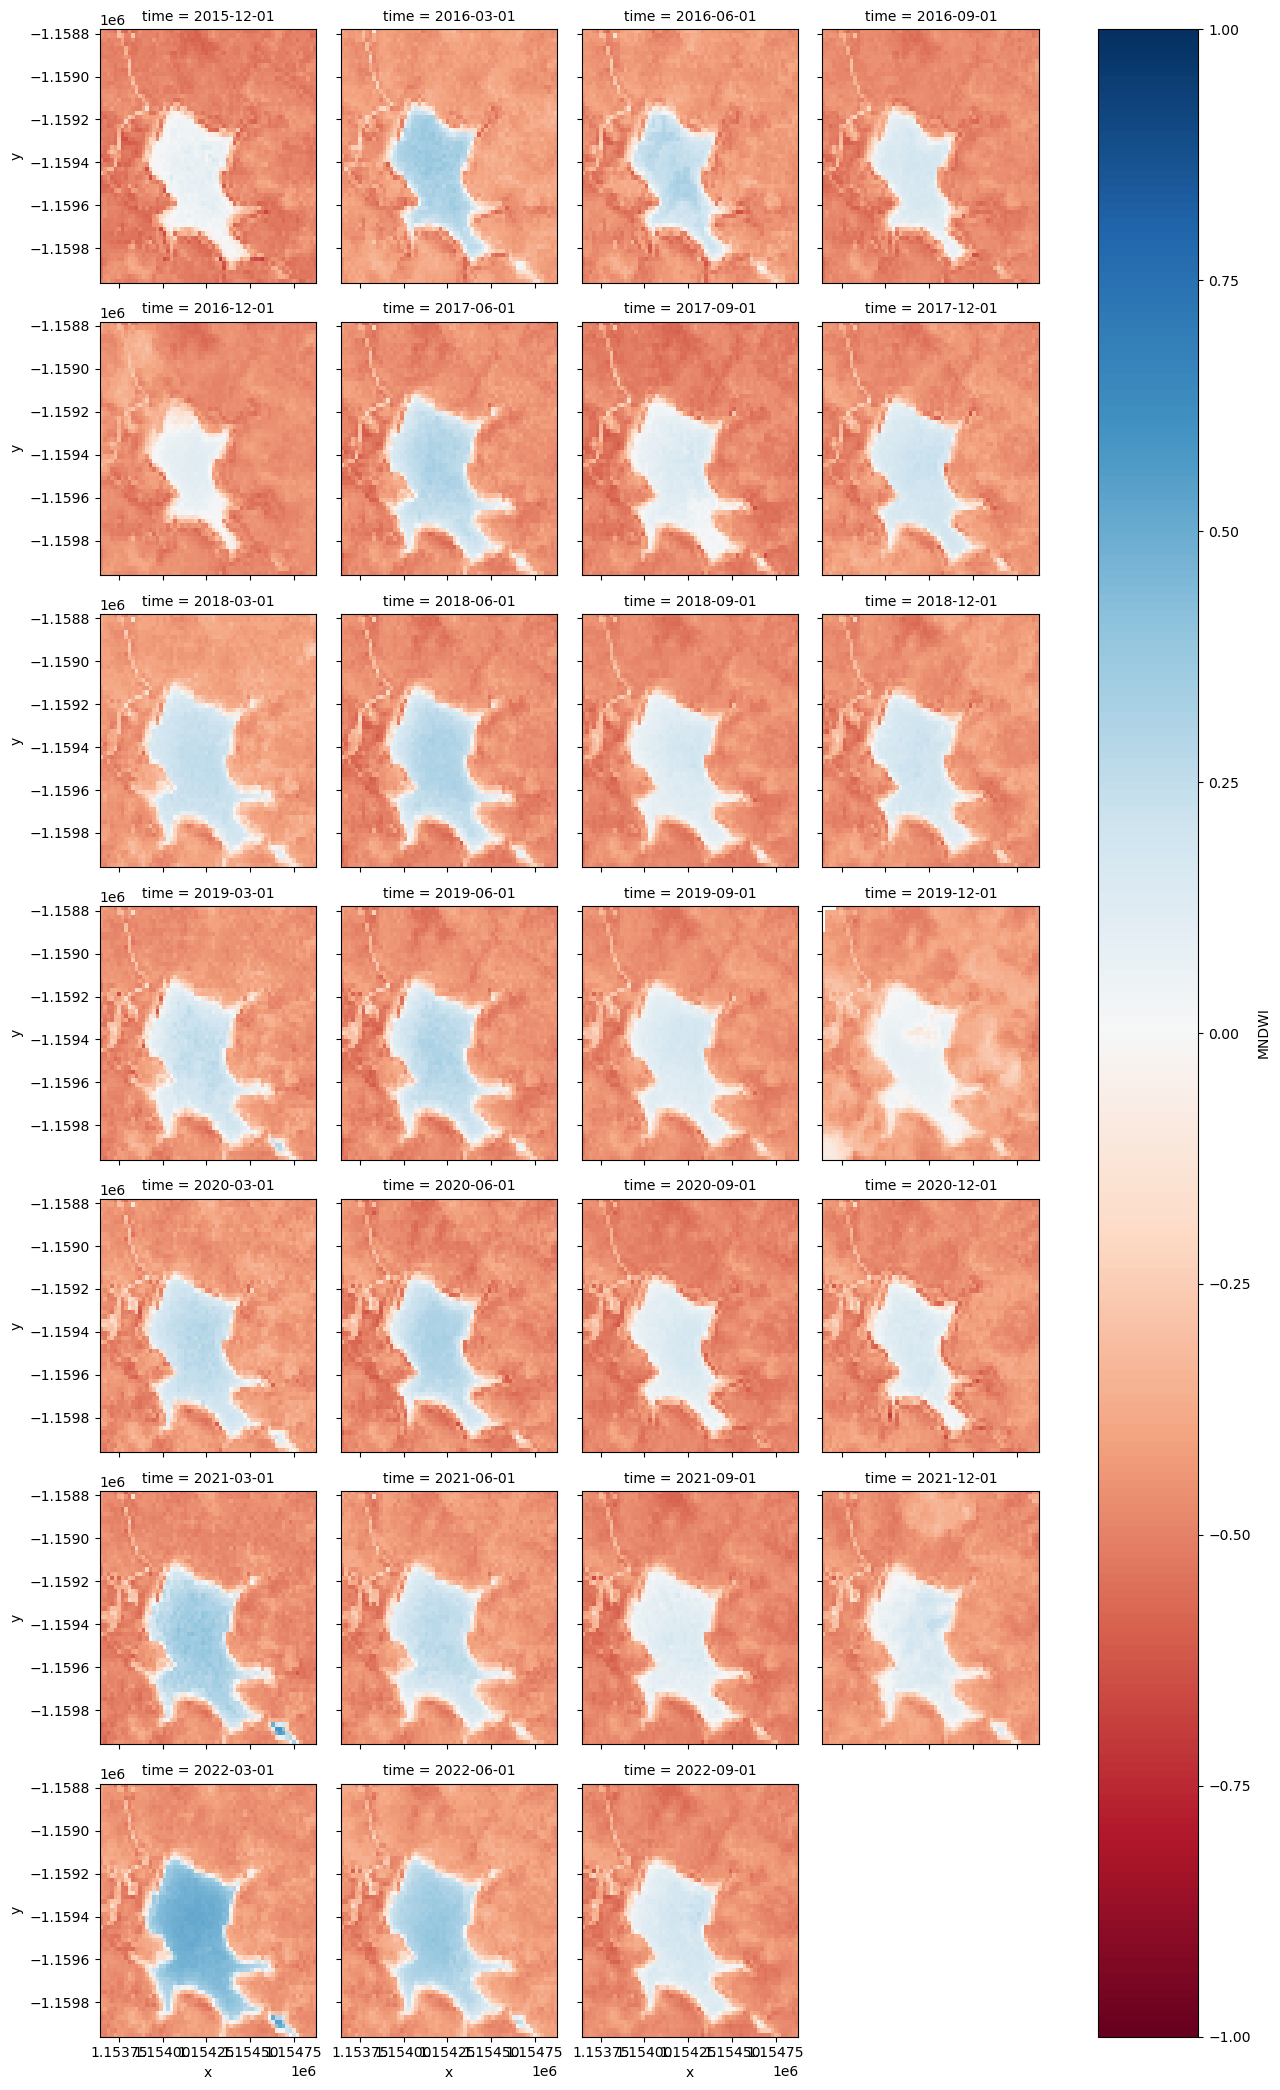

In [26]:
mndwi.plot.imshow(col="time", col_wrap=4, cmap="RdBu", vmax=1, vmin=-1);

### Animating time series
In the next cell, we plot the dataset we loaded above as an animation GIF, using the [xr_animation](../How_to_guides/Animated_timeseries.ipynb) function.
The `output_path` will be saved in the directory where the script is found and you can change the names to prevent file overwrites.

Exporting animation to water_extent.gif


  0%|          | 0/27 (0.0 seconds remaining at ? frames/s)

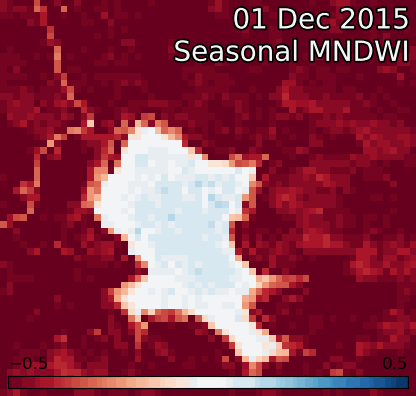

In [40]:
out_path = "water_extent.gif"

xr_animation(
    ds=mndwi.to_dataset(name="MNDWI"),
    output_path=out_path,
    bands=["MNDWI"],
    show_text="Seasonal MNDWI",
    interval=500,
    width_pixels=300,
    show_colorbar=True,
    imshow_kwargs={"cmap": "RdBu", "vmin": -0.5, "vmax": 0.5},
    colorbar_kwargs={"colors": "black"},
)

# Plot animated gif
plt.close()
Image(filename=out_path)

## Calculate the area per pixel
The number of pixels can be used to calculate the area of the waterbody if the pixel area is known. 
Run the following cell to generate the necessary constants for performing this conversion.

In [41]:
pixel_length = query["resolution"][1]  # in metres
m_per_km = 1000  # conversion from metres to kilometres
area_per_pixel = pixel_length**2 / m_per_km**2

### Calculating the extent of water

Calculates the area of pixels classified as water (if MNDWI is > 0, then water).

In [42]:
water = mndwi.where(mndwi > 0)
area_ds = water.where(np.isnan(water), 1)
ds_valid_water_area = area_ds.sum(dim=["x", "y"]) * area_per_pixel

### Plot seasonal time series from the `Start year` to `End year`

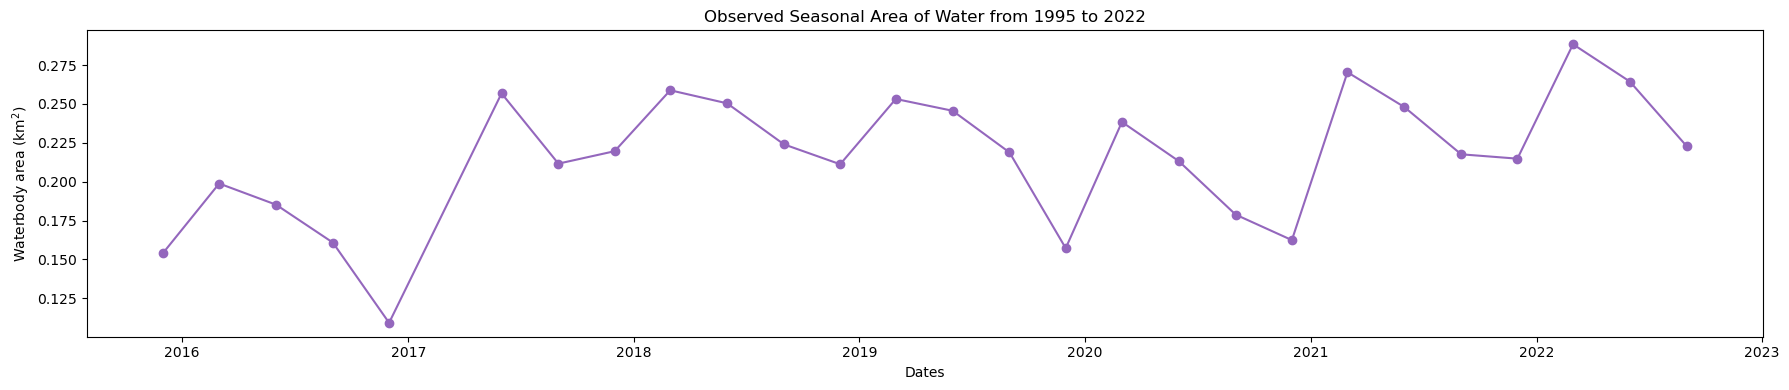

In [43]:
plt.figure(figsize=(18, 4))
ds_valid_water_area.plot(marker="o", color="#9467bd")
plt.title(f"Observed Seasonal Area of Water from {start_year} to {end_year}")
plt.xlabel("Dates")
plt.ylabel("Waterbody area (km$^2$)")
plt.tight_layout()

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# ====================== LOAD RAINFALL ======================
rainfall = pd.read_csv('IDCJAC0001_027058_Data1.csv')

rainfall['date'] = pd.to_datetime(rainfall[['Year', 'Month']].assign(day=1))
rainfall = rainfall[['date', 'Monthly Precipitation Total (millimetres)']].copy()
rainfall.rename(columns={'Monthly Precipitation Total (millimetres)': 'rainfall_mm'}, inplace=True)

# ====================== FIX WATER AREA DATA ======================
# Convert xarray DataArray to pandas Series with proper datetime index
water_area = ds_valid_water_area.to_pandas()           # This usually fixes the 1970 issue

# Optional: Make sure the index is datetime
if not isinstance(water_area.index, pd.DatetimeIndex):
    water_area.index = pd.to_datetime(water_area.index)

# ====================== CREATE COMBINED DATAFRAME ======================
# Resample rainfall to match water area dates if needed
combined = pd.DataFrame({
    'water_area_km2': water_area
})

# Add rainfall (align by nearest date)
combined = combined.join(rainfall.set_index('date'), how='left')

# Optional: Add 3-month rolling rainfall for smoother trend
combined['rainfall_3m_mm'] = combined['rainfall_mm'].rolling(3, center=True).mean()

# ====================== EXPORT TO CSV ======================
combined.to_csv('Badu_Island_WaterArea_Rainfall.csv')
print("✅ CSV file saved: 'Badu_Island_WaterArea_Rainfall.csv'")

# Show first few rows to check
print("\nFirst 6 rows of combined data:")
print(combined.head())

✅ CSV file saved: 'Badu_Island_WaterArea_Rainfall.csv'

First 6 rows of combined data:
            water_area_km2  rainfall_mm  rainfall_3m_mm
time                                                   
2015-12-01          0.1540        114.2             NaN
2016-03-01          0.1988        177.6      100.400000
2016-06-01          0.1852          9.4       62.533333
2016-09-01          0.1608          0.6      136.333333
2016-12-01          0.1092        399.0      140.733333


Updated Plotting Code (with fixed dates)

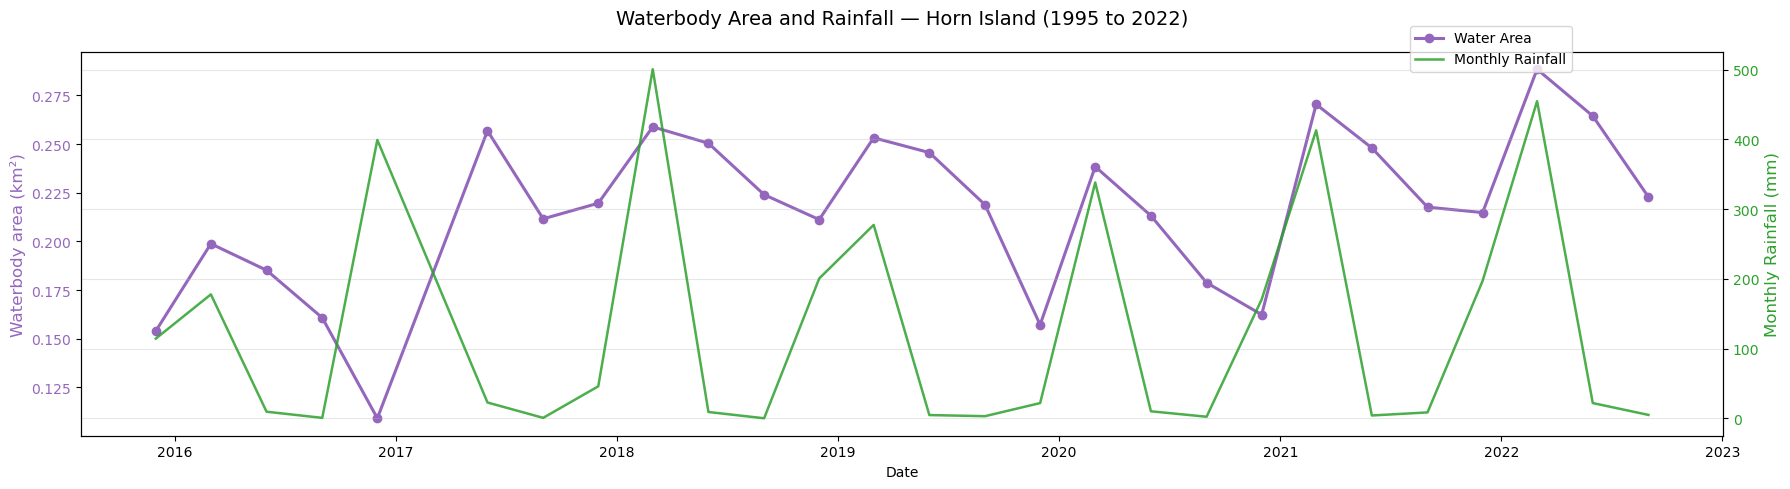

In [46]:
# ====================== PLOTTING ======================
fig, ax1 = plt.subplots(figsize=(18, 5))

ax1.plot(combined.index, combined['water_area_km2'], 
         marker="o", color="#9467bd", linewidth=2.2, label="Water Area")

ax1.set_xlabel("Date")
ax1.set_ylabel("Waterbody area (km²)", color="#9467bd", fontsize=12)
ax1.tick_params(axis='y', labelcolor="#9467bd")

ax2 = ax1.twinx()
ax2.plot(combined.index, combined['rainfall_mm'], 
         color="#2ca02c", linewidth=1.8, alpha=0.85, label="Monthly Rainfall")

ax2.set_ylabel("Monthly Rainfall (mm)", color="#2ca02c", fontsize=12)
ax2.tick_params(axis='y', labelcolor="#2ca02c")

plt.title(f"Waterbody Area and Rainfall — Horn Island ({start_year} to {end_year})", 
          fontsize=14, pad=20)

fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.95))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

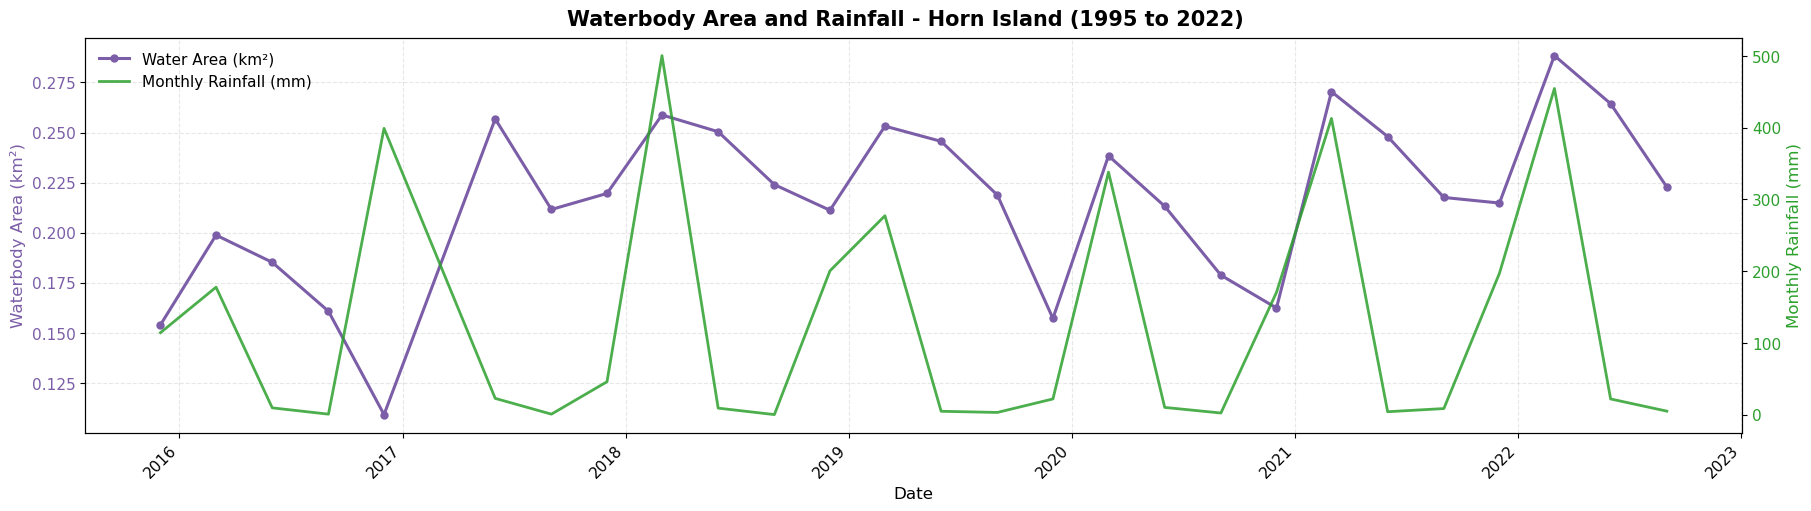

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ====================== STYLE ======================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

# ====================== FIGURE ======================
fig, ax1 = plt.subplots(figsize=(18, 5), constrained_layout=True)

# ====================== WATER AREA ======================
ax1.plot(
    combined.index,
    combined['water_area_km2'],
    marker="o",
    markersize=5,
    color="#7b5ea7",   # slightly softer purple
    linewidth=2.2,
    label="Water Area (km²)"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Waterbody Area (km²)", color="#7b5ea7")
ax1.tick_params(axis='y', labelcolor="#7b5ea7")

# ====================== RAINFALL ======================
ax2 = ax1.twinx()

ax2.plot(
    combined.index,
    combined['rainfall_mm'],
    color="#2ca02c",
    linewidth=2,
    alpha=0.85,
    label="Monthly Rainfall (mm)"
)

ax2.set_ylabel("Monthly Rainfall (mm)", color="#2ca02c")
ax2.tick_params(axis='y', labelcolor="#2ca02c")

# ====================== DATE FORMATTING ======================
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# ====================== TITLE ======================
fig.suptitle(
    f"Waterbody Area and Rainfall - Horn Island ({start_year} to {end_year})",
    fontsize=15,
    fontweight="bold"
)

# ====================== LEGEND ======================
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=False
)

# ====================== GRID ======================
ax1.grid(True, linestyle="--", alpha=0.3)

# ====================== SAVE ======================
fig.savefig(
    "water_rainfall_horn_island.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Optional: also save as vector (great for reports/publication)
fig.savefig(
    "water_rainfall_horn_island.pdf",
    bbox_inches="tight"
)

# ====================== SHOW ======================
plt.show()
plt.close(fig)

In [49]:
# Find index of min and max
min_idx = ds_valid_water_area.argmin(dim="time")
max_idx = ds_valid_water_area.argmax(dim="time")

# Get the actual dates
min_date = ds_valid_water_area.time.isel(time=min_idx).values
max_date = ds_valid_water_area.time.isel(time=max_idx).values

min_value = ds_valid_water_area.min().values
max_value = ds_valid_water_area.max().values

print(f"Minimum water area: {min_value:.5f} km² on {min_date}")
print(f"Maximum water area: {max_value:.5f} km² on {max_date}")

Minimum water area: 0.10920 km² on 2016-12-01T00:00:00.000000000
Maximum water area: 0.28840 km² on 2022-03-01T00:00:00.000000000


## Determine minimum and maximum water extent
The next cell extracts the minimum and maximum extent of water from the dataset using the `min` and `max` functions. We then add the dates to an `xarray.DataArray`.

In [50]:
min_water_area_date, max_water_area_date = min(ds_valid_water_area), max(
    ds_valid_water_area
)
time_da = xr.DataArray(
    [min_water_area_date.time.values, max_water_area_date.time.values], dims=["time"]
)

print(time_da)

<xarray.DataArray (time: 2)> Size: 16B
array(['2016-12-01T00:00:00.000000000', '2022-03-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Dimensions without coordinates: time


### Plot the minimum and maximum water extents
Plot the water classified pixels for the two dates where we have the minimum and maximum surface water extent.

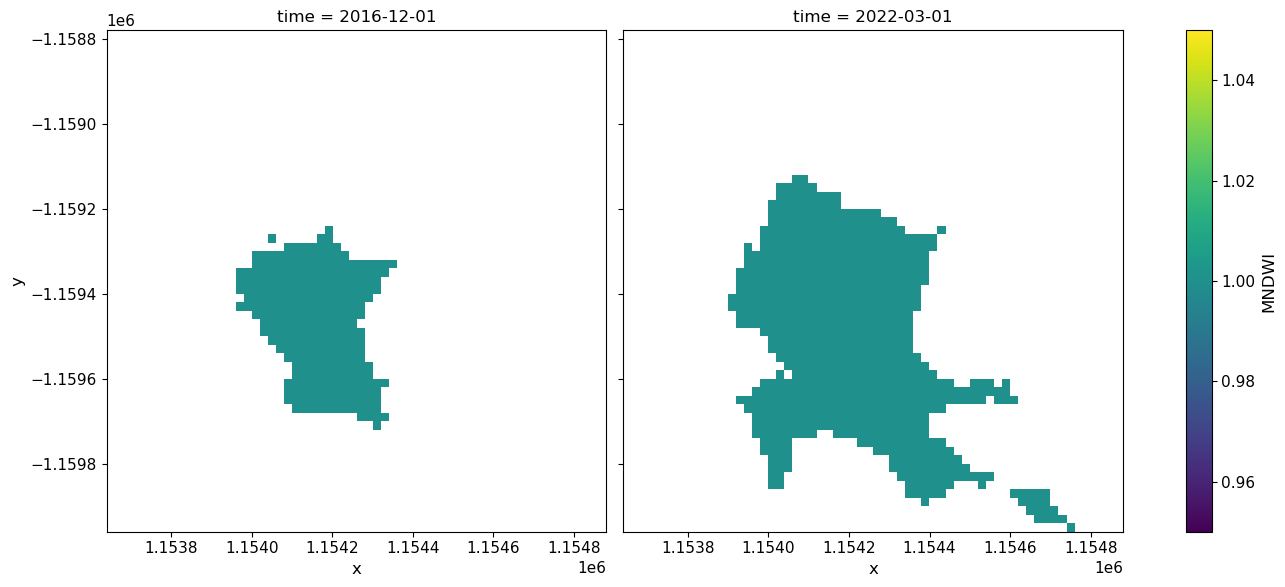

In [51]:
area_ds.sel(time=time_da).plot.imshow(col="time", col_wrap=2, figsize=(14, 6));
#Save at high resolution
plt.savefig('Graph1South.png', dpi=300, bbox_inches='tight')

## Compare two time periods
The following cells determine the maximum extent of water for two different years. 

* `baseline_year` : The baseline year for the analysis
* `analysis_year` : The year to compare to the baseline year

In [52]:
baseline_time = "2019-03-01"
analysis_time = "2020-03-01"

baseline_ds, analysis_ds = ds_valid_water_area.sel(
    time=baseline_time, method="nearest"
), ds_valid_water_area.sel(time=analysis_time, method="nearest")

A new dataArray is created to store the new date from the `maximum water extent` for the two years

In [53]:
time_da = xr.DataArray(
    [baseline_ds.time.values, analysis_ds.time.values], dims=["time"]
)

### Plot the water extent of the MNDWI product for the two chosen periods

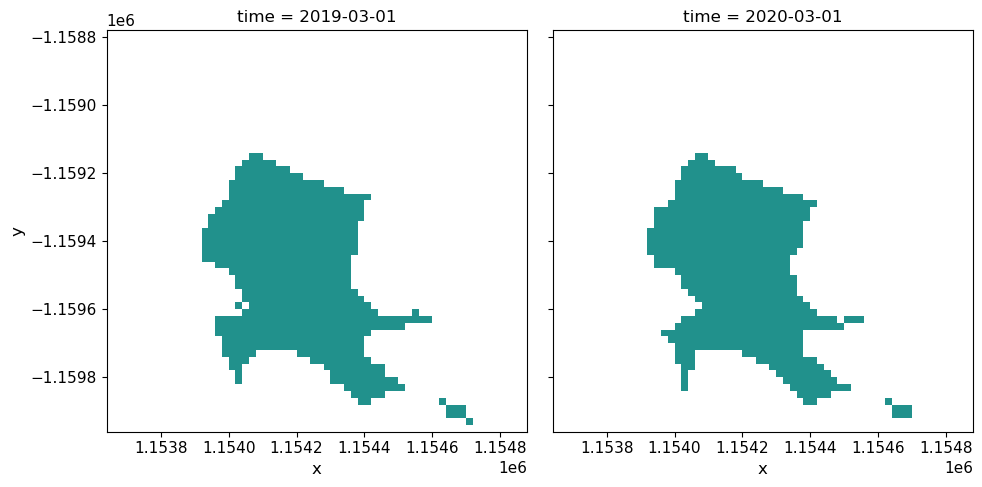

In [54]:
area_ds.sel(time=time_da).plot(
    col="time",
    col_wrap=2,
    robust=True,
    figsize=(10, 5),
    cmap="viridis",
    add_colorbar=False,
);

## Calculating the change between two time periods
The cells below calculate the amount of water gain, loss and no change for the two time periods.

In [55]:
# Extract the two time periods
ds_selected = area_ds.where(area_ds == 1, 0).sel(time=time_da)

analyse_total_value = ds_selected[1]
change = analyse_total_value - ds_selected[0]

water_appeared = change.where(change == 1)
permanent_water = change.where((change == 0) & (analyse_total_value == 1))
permanent_land = change.where((change == 0) & (analyse_total_value == 0))

water_disappeared = change.where(change == -1)

The cell below calculates the area of water extent for water_loss, water_gain, permanent water and land 

In [56]:
total_area = analyse_total_value.count().values * area_per_pixel
water_apperaed_area = water_appeared.count().values * area_per_pixel
permanent_water_area = permanent_water.count().values * area_per_pixel
water_disappeared_area = water_disappeared.count().values * area_per_pixel

### Plot the change in water 

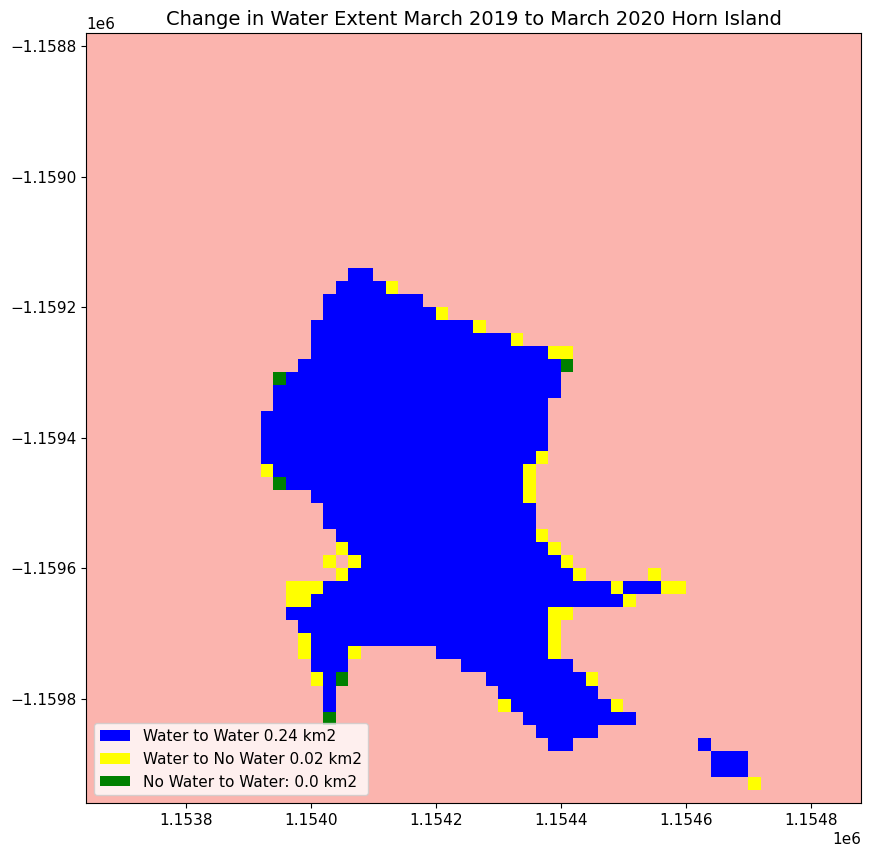

In [58]:
water_appeared_color = "Green"
water_disappeared_color = "Yellow"
stable_color = "Blue"
land_color = "Brown"

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ds_selected[1].plot.imshow(cmap="Pastel1", add_colorbar=False, add_labels=False, ax=ax)
water_appeared.plot.imshow(
    cmap=ListedColormap([water_appeared_color]),
    add_colorbar=False,
    add_labels=False,
    ax=ax,
)
water_disappeared.plot.imshow(
    cmap=ListedColormap([water_disappeared_color]),
    add_colorbar=False,
    add_labels=False,
    ax=ax,
)

permanent_water.plot.imshow(
    cmap=ListedColormap([stable_color]), add_colorbar=False, add_labels=False, ax=ax
)

plt.legend(
    [
        Patch(facecolor=stable_color),
        Patch(facecolor=water_disappeared_color),
        Patch(facecolor=water_appeared_color),
        Patch(facecolor=land_color),
    ],
    [
        f"Water to Water {round(permanent_water_area, 2)} km2",
        f"Water to No Water {round(water_disappeared_area, 2)} km2",
        f"No Water to Water: {round(water_apperaed_area, 2)} km2",
    ],
    loc="lower left",
)

#Title
plt.title('Change in Water Extent March 2019 to March 2020 Horn Island')
#Save at high resolution
plt.savefig('WaterXHorn.png', dpi=300, bbox_inches='tight')

## Next steps


Return to the "Analysis parameters" section, modify some values (e.g. `lat`, `lon`, `start_year`, `end_year`) and re-run the analysis.
You can use the interactive map in the "View the selected location" section to find new central latitude and longitude values by panning and zooming, and then clicking on the area you wish to extract location values for.
You can also use Google maps to search for a location you know, then return the latitude and longitude values by clicking the map.

Change the year also in "Compare Two Time Periods - a Baseline and an Analysis" section, (e.g. `base_year`, `analyse_year`) and re-run the analysis.

---

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).

If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** February 2025

**Compatible datacube version:**

In [22]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->